# Estimate of videos per CEO per year

In [29]:
%pip install pandas google-api-python-client matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 85.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 91.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 58.0 MB/s  0:00:00

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## Read dataset

In [ ]:
import pandas as pd
df = pd.read_csv('data/global-fortune-500-2022.csv')
print(df.to_string())

## Get N random CEOs

In [ ]:
import json
import pandas as pd

N = 50

with open("ceo_list.json") as f:
    ceo_list = json.load(f)

available = [
    x for x in ceo_list
    if not x["videos_collected"]
]

sampled = available[:N]

sampled_ceos = pd.DataFrame(sampled)

print(sampled_ceos.to_string())

## Get interviews published in 2022

In [ ]:
import os
import json
from dotenv import load_dotenv
from googleapiclient.discovery import build

load_dotenv()

youtube = build(
    "youtube",
    "v3",
    developerKey=os.getenv("YOUTUBE_API_KEY")
)

os.makedirs("output/estimation", exist_ok=True)

# Search + get details + save everything
if len(sampled_ceos) == 0:
    print("No new CEOs left to collect.")
else:
    for _, row in sampled_ceos.iterrows():
        ceo = row["CEO"]

        search_response = youtube.search().list(
            part="snippet",
            q=f"{ceo} interview",
            type="video",
            publishedAfter="2022-01-01T00:00:00Z",
            publishedBefore="2023-01-01T00:00:00Z",
            maxResults=50
        ).execute()

        video_ids = [
            item["id"]["videoId"]
            for item in search_response["items"]
        ]

        details_response = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        ).execute()

        # Save everything together
        output = {
            "ceo": ceo,
            "search_results": search_response,
            "video_details": details_response
        }

        with open(f"output/estimation/{ceo}.json", "w") as f:
            json.dump(output, f, indent=2)

C:\Users\sonia.nicoletti\AppData\Local\Temp\ipykernel_20116\1510600080.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


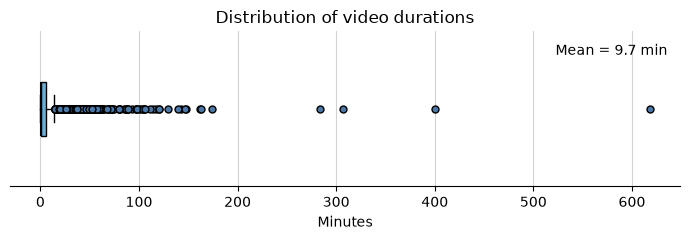

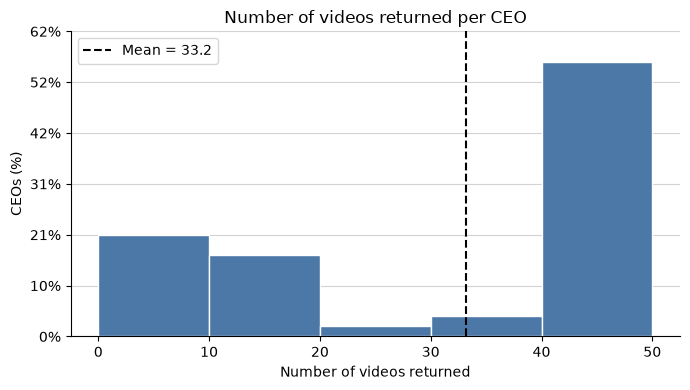

In [44]:
import os
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


def duration_to_seconds(duration):
    hours = re.search(r"(\d+)H", duration)
    minutes = re.search(r"(\d+)M", duration)
    seconds = re.search(r"(\d+)S", duration)

    return (
        (int(hours.group(1)) * 3600 if hours else 0) +
        (int(minutes.group(1)) * 60 if minutes else 0) +
        (int(seconds.group(1)) if seconds else 0)
    )


# collect individual video durations
all_durations = []

for file in os.listdir("output/estimation"):
    if file.endswith(".json"):
        with open(f"output/estimation/{file}") as f:
            data = json.load(f)

        for video in data["video_details"]["items"]:
            duration = duration_to_seconds(video["contentDetails"]["duration"]) / 60
            all_durations.append(duration)

# Plot 1: video duration
mean_duration = np.mean(all_durations)
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.boxplot(
    all_durations,
    vert=False,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor="#6baed6"),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markersize=5,
        markerfacecolor="#4c78a8",
        markeredgecolor="black"
    )
)
mean_patch = Patch(
    facecolor="none",
    edgecolor="none",
    label=f"Mean = {mean_duration:.1f} min"
)
ax.legend(
    handles=[mean_patch],
    frameon=False,
    loc="upper right"
)
ax.set_xlabel("Minutes")
ax.set_yticks([])
ax.set_title("Distribution of video durations")
ax.grid(
    axis="x",
    color="lightgrey",
    linewidth=0.8
)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

# Plot 2: number of videos per CEO
plt.figure(figsize=(7, 4))
counts, bins, patches = plt.hist(
    video_counts,
    bins=range(0, max(video_counts) + 5, 10),
    color="#4c78a8",
    edgecolor="white"
)
# convert y axis to percentages
total = len(video_counts)
plt.gca().set_yticks(
    plt.gca().get_yticks()
)
plt.gca().set_yticklabels(
    [f"{y/total*100:.0f}%" for y in plt.gca().get_yticks()]
)
plt.axvline(
    np.mean(video_counts),
    color="black",
    linestyle="--",
    label=f"Mean = {np.mean(video_counts):.1f}"
)
plt.xlabel("Number of videos returned")
plt.ylabel("CEOs (%)")
plt.title("Number of videos returned per CEO")
ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.8
)
plt.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()